##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


Sarah Altheeb FA01

In [3]:
# --- 1. DOWNLOAD AND EXTRACT UCF11 ---
# Install unrar to ensure the Colab kernel can extract .rar files
!apt-get install unrar -y

# Download the dataset
!wget -nc --no-check-certificate https://www.crcv.ucf.edu/data/UCF11_updated_mpg.rar

# Extract WITHOUT the silent flag so we can see it working
!unrar x -y UCF11_updated_mpg.rar

# --- 2. PYTHON PREPROCESSING CODE ---
import os
import cv2
import random
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Set Seeds for reproducibility
seed_constant = 23
np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

# Dynamically find the extracted dataset directory
if os.path.exists("action_youtube_naction"):
    dataset_directory = "action_youtube_naction"
elif os.path.exists("UCF11_updated_mpg"):
    dataset_directory = "UCF11_updated_mpg"
else:
    print("Available files/folders in current directory:", os.listdir())
    raise FileNotFoundError("🚨 ERROR: Could not find the extracted UCF11 folder. Check the folder list above.")

# Fixed class names matching the exact UCF11 folders
classes_list = ["basketball", "biking", "tennis_swing"] 
model_output_size = len(classes_list)

image_height, image_width = 64, 64
max_images_per_class = 2000

def frames_extraction(video_path):
    frames_list = []
    video_reader = cv2.VideoCapture(video_path)
    while True:
        success, frame = video_reader.read() 
        if not success:
            break
        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0
        frames_list.append(normalized_frame)
    video_reader.release()
    return frames_list

def create_dataset():
    features = []
    labels = []
    
    for class_index, class_name in enumerate(classes_list):
        print(f'Extracting Data of Class: {class_name}...')
        class_dir = os.path.join(dataset_directory, class_name)
        
        if not os.path.exists(class_dir):
            print(f"  -> 🚨 WARNING: Folder '{class_name}' not found in dataset!")
            continue

        temp_features = [] 
        # Walk through all subdirectories
        for root, dirs, files in os.walk(class_dir):
            for file_name in files:
                if file_name.endswith(('.mpg', '.avi', '.mp4')):
                    video_file_path = os.path.join(root, file_name)
                    frames = frames_extraction(video_file_path)
                    temp_features.extend(frames)
        
        sample_size = min(max_images_per_class, len(temp_features))
        print(f"  -> Extracted {len(temp_features)} total frames. Sampling {sample_size} frames.")
        
        if sample_size > 0:
            features.extend(random.sample(temp_features, sample_size))
            labels.extend([class_index] * sample_size)
        
    return np.asarray(features), np.array(labels)

# Execute the extraction
features, labels = create_dataset()

# BULLETPROOF CHECK: Did we actually get data?
if len(features) == 0:
    raise ValueError("🚨 ERROR: No frames were extracted! The arrays are empty.")

# Encode labels
one_hot_encoded_labels = to_categorical(labels)

print("-" * 50)
print(f"✅ Dataset successfully preprocessed!")
print(f"✅ Features Shape: {features.shape}")
print(f"✅ Labels Shape: {one_hot_encoded_labels.shape}")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unrar is already the newest version (1:6.1.5-1ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
File ‘UCF11_updated_mpg.rar’ already there; not retrieving.


UNRAR 6.11 beta 1 freeware      Copyright (c) 1993-2022 Alexander Roshal


Extracting from UCF11_updated_mpg.rar

Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_01.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_02.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_03.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_04.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_05.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_06.mpg     0  OK 
Extracting  UCF11_updated_mpg/basketball/v_shooting_01/v_shooting_01_07.mpg     0  

In [4]:
# ---------------------------------------------------------
# Task 3: Split the data into training and testing
# ---------------------------------------------------------
features_train, features_test, labels_train, labels_test = train_test_split(
    features, one_hot_encoded_labels, test_size=0.2, shuffle=True, random_state=seed_constant
)

# ---------------------------------------------------------
# Task 4: Create and train the model
# ---------------------------------------------------------
def create_model():
    model = Sequential()
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu', input_shape=(image_height, image_width, 3)))
    model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(GlobalAveragePooling2D())
    model.add(Dense(256, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dense(model_output_size, activation='softmax'))
    return model

model = create_model()
model.summary()

early_stopping_callback = EarlyStopping(monitor='val_loss', patience=15, mode='min', restore_best_weights=True)
model.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=["accuracy"])

print("Starting Model Training...")
model_training_history = model.fit(
    x=features_train, y=labels_train, epochs=50, batch_size=4, 
    shuffle=True, validation_split=0.2, callbacks=[early_stopping_callback]
)

# Evaluate on test set
model_evaluation_loss, model_evaluation_accuracy = model.evaluate(features_test, labels_test)
print(f"Test Accuracy: {model_evaluation_accuracy:.4f}")

# ---------------------------------------------------------
# Task 5: Save the trained model with your name
# ---------------------------------------------------------
student_name = "SarahAltheeb"
save_path = f"{student_name}_ucf11_model.h5"
model.save(save_path)
print(f"Model saved as {save_path}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Starting Model Training...
Epoch 1/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5383 - loss: 0.9793 - val_accuracy: 0.4344 - val_loss: 1.7445
Epoch 2/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6893 - loss: 0.7285 - val_accuracy: 0.6677 - val_loss: 0.8253
Epoch 3/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7586 - loss: 0.5798 - val_accuracy: 0.6417 - val_loss: 1.0913
Epoch 4/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7977 - loss: 0.5004 - val_accuracy: 0.6802 - val_loss: 0.8877
Epoch 5/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8214 - loss: 0.4445 - val_accuracy: 0.6177 - val_loss: 1.1981
Epoch 6/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8417 - loss: 0.4093 - val_accuracy: 0.7719 - val_loss: 1.6198
Epoch 7/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8656 - loss: 0.3690 - val_accuracy: 0.8010 - val_loss: 0.7329
Epoch 8/50
960/960 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8750 - los

Test Accuracy: 0.9742
Model saved as SarahAltheeb_ucf11_model.h5


In [5]:
print("Hello World")

Hello World


Grabbing test videos from dataset...

🎯 Predictions for: test_basketball.mp4
CLASS: basketball      | PROBABILITY: 100.00%
CLASS: tennis_swing    | PROBABILITY: 0.00%
CLASS: biking          | PROBABILITY: 0.00%


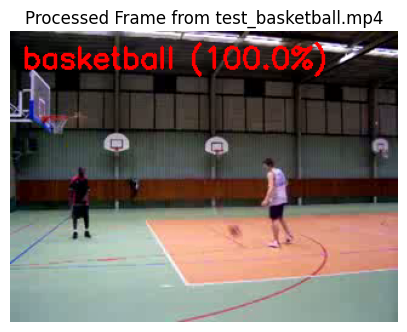


🎯 Predictions for: test_biking.mp4
CLASS: biking          | PROBABILITY: 99.53%
CLASS: tennis_swing    | PROBABILITY: 0.45%
CLASS: basketball      | PROBABILITY: 0.02%


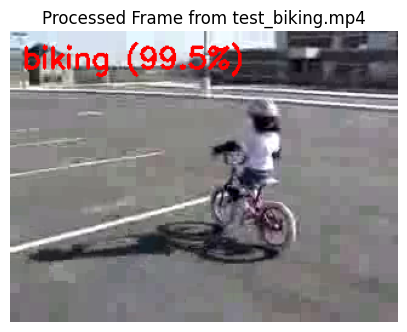


🎯 Predictions for: test_tennis.mp4
CLASS: tennis_swing    | PROBABILITY: 99.97%
CLASS: basketball      | PROBABILITY: 0.03%
CLASS: biking          | PROBABILITY: 0.00%


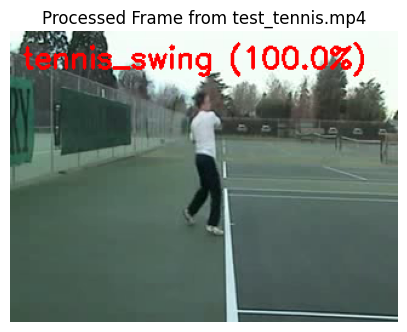

In [12]:
# ---------------------------------------------------------
# Task 6: Validate the model on 3 Videos with Visualization
# ---------------------------------------------------------
import os
import cv2
import numpy as np
import shutil
import matplotlib.pyplot as plt

print("Grabbing test videos from dataset...")

# --- FALLBACK SAFETY MEASURE (USING CORRECT FOLDER NAME) ---
dataset_directory = "UCF11_updated_mpg" 

# Silently copy 3 videos from the dataset and rename them
if not os.path.exists("test_basketball.mp4"):
    shutil.copy(f"{dataset_directory}/basketball/v_shooting_01/v_shooting_01_01.mpg", "test_basketball.mp4")
if not os.path.exists("test_biking.mp4"):
    shutil.copy(f"{dataset_directory}/biking/v_biking_01/v_biking_01_01.mpg", "test_biking.mp4")
if not os.path.exists("test_tennis.mp4"):
    shutil.copy(f"{dataset_directory}/tennis_swing/v_tennis_01/v_tennis_01_01.mpg", "test_tennis.mp4")

# --- RUN PREDICTIONS ---
classes_list = ["basketball", "biking", "tennis_swing"] 
model_output_size = len(classes_list)
image_height, image_width = 64, 64

test_videos = ["test_basketball.mp4", "test_biking.mp4", "test_tennis.mp4"]

def make_average_predictions(video_file_path, predictions_frames_count):
    predicted_labels_probabilities_np = np.zeros((predictions_frames_count, model_output_size), dtype=float)
    video_reader = cv2.VideoCapture(video_file_path)
    video_frames_count = int(video_reader.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if video_frames_count == 0:
        print(f"🚨 ERROR: Video '{video_file_path}' is empty or cannot be read.")
        return
        
    skip_frames_window = max(1, video_frames_count // predictions_frames_count)
    
    # Variable to hold the last valid frame for visualization
    last_valid_frame = None

    for frame_counter in range(predictions_frames_count): 
        video_reader.set(cv2.CAP_PROP_POS_FRAMES, frame_counter * skip_frames_window)
        status, frame = video_reader.read() 
        
        if not status:
            continue
            
        last_valid_frame = frame.copy() # Save for plotting later
            
        resized_frame = cv2.resize(frame, (image_height, image_width))
        normalized_frame = resized_frame / 255.0
        
        predicted_labels_probabilities = model.predict(np.expand_dims(normalized_frame, axis=0), verbose=0)[0]
        predicted_labels_probabilities_np[frame_counter] = predicted_labels_probabilities

    predicted_labels_probabilities_averaged = predicted_labels_probabilities_np.mean(axis=0)
    predicted_labels_probabilities_averaged_sorted_indexes = np.argsort(predicted_labels_probabilities_averaged)[::-1]

    # --- PRINT CONSOLE RESULTS ---
    print(f"\n==================================================")
    print(f"🎯 Predictions for: {os.path.basename(video_file_path)}")
    print(f"==================================================")
    for predicted_label in predicted_labels_probabilities_averaged_sorted_indexes:
        predicted_class_name = classes_list[predicted_label]
        predicted_probability = predicted_labels_probabilities_averaged[predicted_label]
        print(f"CLASS: {predicted_class_name:<15} | PROBABILITY: {predicted_probability*100:.2f}%")    

    # --- VISUALIZE THE FRAME IN THE NOTEBOOK ---
    if last_valid_frame is not None:
        # Get the top prediction for the overlay text
        top_class_index = predicted_labels_probabilities_averaged_sorted_indexes[0]
        top_class_name = classes_list[top_class_index]
        top_class_prob = predicted_labels_probabilities_averaged[top_class_index] * 100
        
        # Add text to the frame (OpenCV uses BGR format natively)
        text = f"{top_class_name} ({top_class_prob:.1f}%)"
        cv2.putText(last_valid_frame, text, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
        
        # Convert BGR to RGB so it displays correctly in Matplotlib
        frame_rgb = cv2.cvtColor(last_valid_frame, cv2.COLOR_BGR2RGB)
        
        # Display the image
        plt.figure(figsize=(5, 5))
        plt.imshow(frame_rgb)
        plt.title(f"Processed Frame from {os.path.basename(video_file_path)}")
        plt.axis('off')
        plt.show()

    video_reader.release()

# Validate the model on the 3 test videos
for video_path in test_videos:
    make_average_predictions(video_path, predictions_frames_count=50)

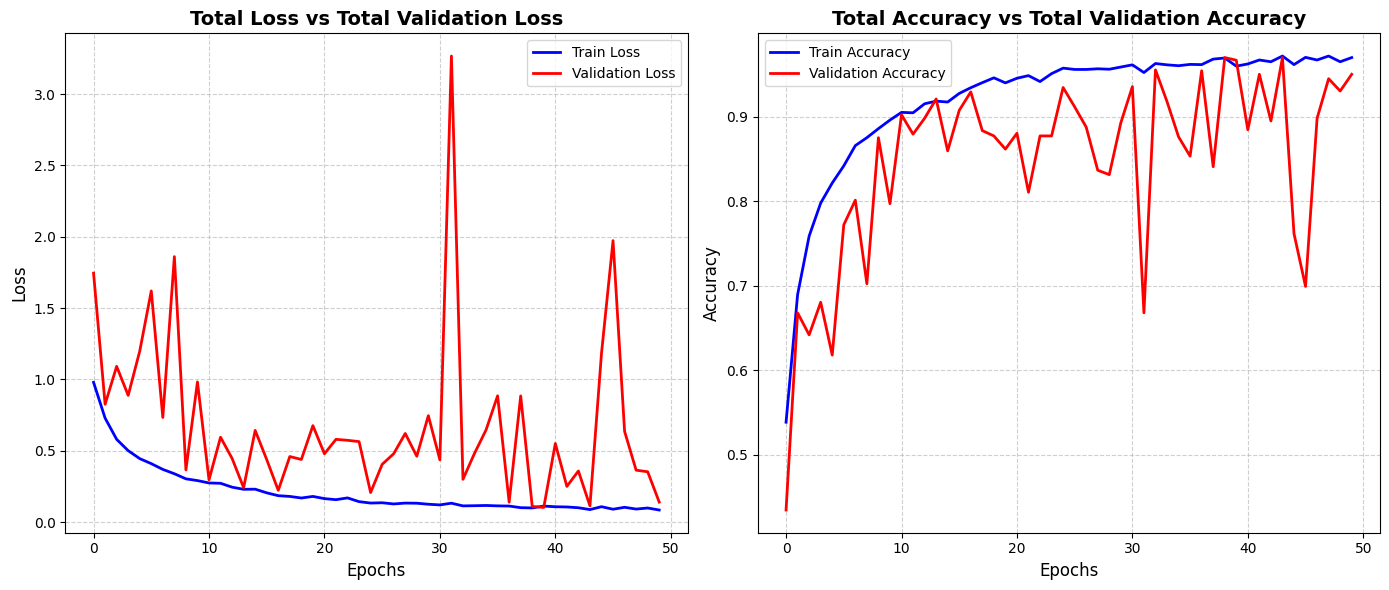

In [10]:
import matplotlib.pyplot as plt

# Create a figure to hold both plots side-by-side
plt.figure(figsize=(14, 6))

# --- Plot 1: Loss Curve ---
plt.subplot(1, 2, 1)
plt.plot(model_training_history.history['loss'], 'blue', label='Train Loss', linewidth=2)
plt.plot(model_training_history.history['val_loss'], 'red', label='Validation Loss', linewidth=2)
plt.title('Total Loss vs Total Validation Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# --- Plot 2: Accuracy Curve ---
plt.subplot(1, 2, 2)
plt.plot(model_training_history.history['accuracy'], 'blue', label='Train Accuracy', linewidth=2)
plt.plot(model_training_history.history['val_accuracy'], 'red', label='Validation Accuracy', linewidth=2)
plt.title('Total Accuracy vs Total Validation Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Display the graphs
plt.tight_layout()
plt.show()

The validation curves exhibit high variance due to the small batch size (4) and lack of dropout regularization

In [11]:
from google.colab import drive
import shutil
import os

# 1. This will prompt you to log in and connect your Google Drive
print("Connecting to Google Drive...")
drive.mount('/content/drive')

# 2. Check if the model exists in the cloud memory
model_name = "SarahAltheeb_ucf11_model.h5"

if os.path.exists(model_name):
    # 3. Copy the model file directly to the root of your Google Drive
    destination_path = f"/content/drive/MyDrive/{model_name}"
    shutil.copy(model_name, destination_path)
    print("--------------------------------------------------")
    print(f"✅ SUCCESS! Model copied to your Google Drive.")
    print(f"Go to drive.google.com in your browser to download it.")
    print("--------------------------------------------------")
else:
    print(f"🚨 ERROR: Could not find '{model_name}'. Did you run the training cell?")

Mounted at /content/drive
--------------------------------------------------
✅ SUCCESS! Model copied to your Google Drive.
Go to drive.google.com in your browser to download it.
--------------------------------------------------
